# InstructPix2Pix - Image vers Image Anime

Notebook pour entraîner et évaluer le modèle InstructPix2Pix pour la conversion image vers image anime.

## 1. Importations et Initialisation
Importation des bibliothèques nécessaires et initialisation du projet.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from torchvision.utils import make_grid

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from anime_gan_i2i.config import load_config
from anime_gan_i2i.data import create_dataloaders
from anime_gan_i2i.infer import run_inference
from anime_gan_i2i.train import run_training
from anime_gan_i2i.utils import denormalize, resolve_device

device = resolve_device()
device

device(type='cuda')

## 2. Chargement de la Configuration du Modèle
Chargement de la configuration spécifique à InstructPix2Pix.

In [2]:
MODEL_CONFIGS = {
    'instruct_pix2pix': 'instruct_pix2pix.yaml',
}

SELECTED_MODEL = 'instruct_pix2pix'
config = load_config(PROJECT_ROOT / 'configs' / MODEL_CONFIGS[SELECTED_MODEL])
config

{'experiment_name': 'instruct_pix2pix_selfie2anime',
 'model_name': 'instruct_pix2pix',
 'mode': 'instruct_pix2pix',
 'seed': 42,
 'data': {'root': '../data/selfie2anime/paired',
  'image_size': 128,
  'num_workers': 2,
  'batch_size': 8,
  'augment': {'random_horizontal_flip': True, 'color_jitter': 0.1},
  'paired_layout': {'train_real': 'train/real',
   'train_anime': 'train/anime',
   'val_real': 'val/real',
   'val_anime': 'val/anime',
   'test_real': 'test/real',
   'test_anime': 'test/anime'}},
 'text_encoder': {'model_name': 'openai/clip-vit-base-patch32',
  'embedding_dim': 512,
  'local_files_only': False,
  'prompt_file': None,
  'default_prompt': None,
  'prompt_templates': ['convert this selfie into clean anime portrait with vivid eyes',
   'turn this portrait into anime style while preserving identity',
   'anime illustration style, soft shading, preserve facial structure',
   'stylize this face into manga-inspired character art']},
 'train': {'epochs': 100,
  'decay_start

## 3. Chargement et Vérification des Données
Création des dataloaders et affichage de la taille des datasets.

In [3]:
loaders = create_dataloaders(config)
{split: len(loader.dataset) for split, loader in loaders.items()}

{'train': 3150, 'val': 175, 'test': 175}

## 4. Affichage d’un Batch d’Images
Visualisation d’un batch d’images d’entraînement.

['turn this portrait into anime style while preserving identity',
 'turn this portrait into anime style while preserving identity',
 'stylize this face into manga-inspired character art',
 'convert this selfie into clean anime portrait with vivid eyes']

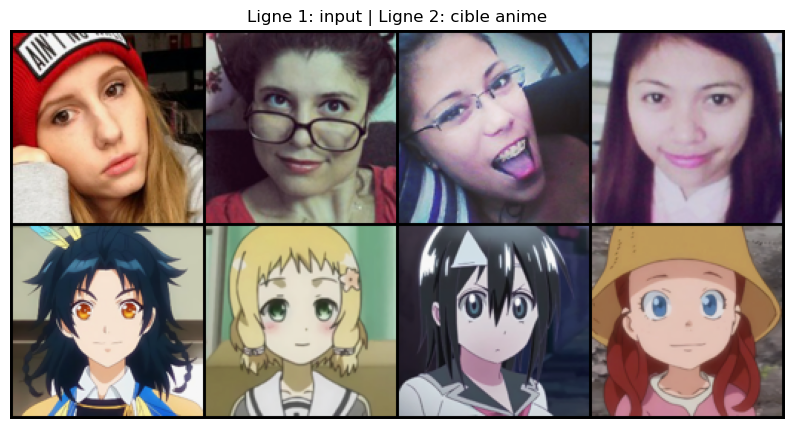

In [4]:
def show_batch(batch, model_name):
    plt.figure(figsize=(10, 10))
    inputs = denormalize(batch['input'][:4])
    targets = denormalize(batch['target'][:4])
    grid = make_grid(torch.cat([inputs, targets], dim=0), nrow=4)
    plt.title('Ligne 1: input | Ligne 2: cible anime')
    if 'text' in batch:
        display(batch['text'][:4])
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.show()

show_batch(next(iter(loaders['train'])), config['model_name'])

## 5. Définition des Hyperparamètres Locaux
Modification des hyperparamètres d’entraînement.

In [5]:
config['train']['epochs'] = 100
config['train']['sample_interval'] = 5
config

{'experiment_name': 'instruct_pix2pix_selfie2anime',
 'model_name': 'instruct_pix2pix',
 'mode': 'instruct_pix2pix',
 'seed': 42,
 'data': {'root': '../data/selfie2anime/paired',
  'image_size': 128,
  'num_workers': 2,
  'batch_size': 8,
  'augment': {'random_horizontal_flip': True, 'color_jitter': 0.1},
  'paired_layout': {'train_real': 'train/real',
   'train_anime': 'train/anime',
   'val_real': 'val/real',
   'val_anime': 'val/anime',
   'test_real': 'test/real',
   'test_anime': 'test/anime'}},
 'text_encoder': {'model_name': 'openai/clip-vit-base-patch32',
  'embedding_dim': 512,
  'local_files_only': False,
  'prompt_file': None,
  'default_prompt': None,
  'prompt_templates': ['convert this selfie into clean anime portrait with vivid eyes',
   'turn this portrait into anime style while preserving identity',
   'anime illustration style, soft shading, preserve facial structure',
   'stylize this face into manga-inspired character art']},
 'train': {'epochs': 100,
  'decay_start

## 6. Entraînement du Modèle
Lancement de l’entraînement et récupération de l’historique.

In [6]:
resume_cfg = config.get('runtime', {}).get('resume_checkpoint')
if resume_cfg:
    resume_checkpoint = Path(resume_cfg)
else:
    last_ckpt = Path(config['runtime']['checkpoint_dir']) / 'last.pt'
    auto_resume = bool(config.get('runtime', {}).get('auto_resume', False))
    resume_checkpoint = last_ckpt if auto_resume and last_ckpt.exists() else None

models, history = run_training(
    config,
    resume_checkpoint=resume_checkpoint if (resume_checkpoint and resume_checkpoint.exists()) else None,
)


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

## 7. Affichage de l’Historique d’Entraînement
Conversion de l’historique en DataFrame et affichage des dernières lignes.

In [7]:
history_df = pd.DataFrame(history)
history_df.tail()

,epoch,g_loss,d_loss,val_l1,psnr,ssim
95,96.0,67.735162,0.075509,0.544045,9.539022,0.131090
96,97.0,67.450876,0.079617,0.552604,9.445626,0.138865
97,98.0,67.402431,0.076443,0.548670,9.482207,0.133126
98,99.0,67.080162,0.070250,0.550537,9.439308,0.131726
99,100.0,67.346718,0.072392,0.562025,9.297564,0.132991


## 8. Courbes d’Entraînement
Tracé des courbes d’entraînement à partir de l’historique.

### Signification des métriques tracées

- `g_loss` : perte du générateur. Elle mesure sa capacité à produire des images crédibles pour tromper les discriminateurs.
- `d_a_loss` : perte du discriminateur du domaine A (souvent photo/réel). Plus elle est basse, plus ce discriminateur distingue bien les faux des vrais.
- `d_b_loss` : perte du discriminateur du domaine B (souvent anime). Interprétation identique à `d_a_loss`.
- `val_cycle_l1` : erreur de cohérence cyclique en validation (`A -> B -> A` et `B -> A -> B`). Plus bas indique une meilleure conservation du contenu.
- `val_identity_l1` : erreur d’identité en validation. Plus bas indique une meilleure préservation de l’image quand une transformation forte n’est pas nécessaire.

Chaque métrique est affichée sur un graphe séparé pour faciliter la lecture.


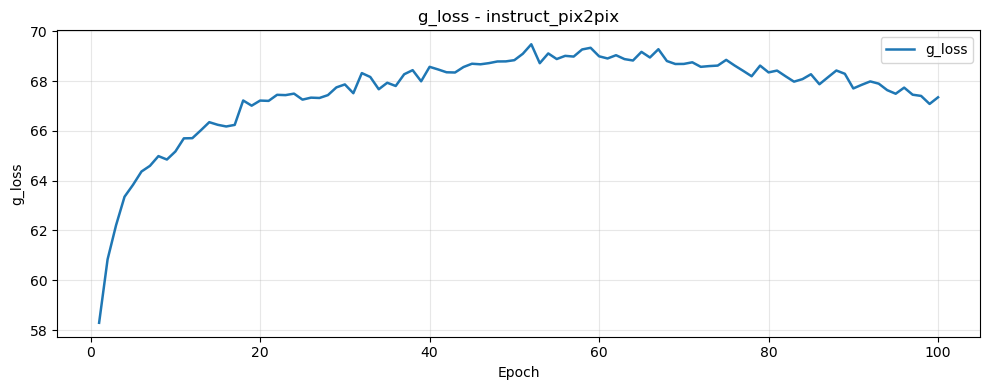

Métriques absentes pour ce modèle : d_a_loss, d_b_loss, val_cycle_l1, val_identity_l1


In [8]:
metrics_to_plot = ["g_loss", "d_a_loss", "d_b_loss", "val_cycle_l1", "val_identity_l1"]
available_metrics = [m for m in metrics_to_plot if m in history_df.columns]
missing_metrics = [m for m in metrics_to_plot if m not in history_df.columns]

x = history_df["epoch"] if "epoch" in history_df.columns else range(1, len(history_df) + 1)

if not available_metrics:
    print("Aucune des métriques demandées n'est disponible dans history_df.")
else:
    for metric in available_metrics:
        plt.figure(figsize=(10, 4))
        plt.plot(x, history_df[metric], linewidth=1.8, label=metric)
        plt.title(f"{metric} - {config['model_name']}")
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

if missing_metrics:
    print("Métriques absentes pour ce modèle :", ", ".join(missing_metrics))


## 9. Inférence sur les Images de Test
Génération d’images anime à partir des images de test.

In [9]:
input_dir = PROJECT_ROOT / 'data' / 'selfie2anime' / 'paired' / 'test' / 'real'
checkpoint_path = Path(config['runtime']['checkpoint_dir']) / 'best.pt'
output_dir = PROJECT_ROOT / 'outputs' / f"inference_{config['model_name']}"
prompt = 'convert this portrait into expressive anime style'
run_inference(config, checkpoint_path, input_dir, output_dir, prompt=prompt)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

PosixPath('/home/johanu/Downloads/cours_uqac/8INF887 - Apprentissage profond - Hiver 2026 - 01/final-project/outputs/inference_instruct_pix2pix')

## 10. Affichage des Résultats d’Inférence
Affichage côte à côte d’une image d’entrée et de sa version générée en style anime.

In [10]:
generated_files = sorted(output_dir.glob('*'))
generated_files[:5]

[PosixPath('/home/johanu/Downloads/cours_uqac/8INF887 - Apprentissage profond - Hiver 2026 - 01/final-project/outputs/inference_instruct_pix2pix/00000.png'),
 PosixPath('/home/johanu/Downloads/cours_uqac/8INF887 - Apprentissage profond - Hiver 2026 - 01/final-project/outputs/inference_instruct_pix2pix/00001.png'),
 PosixPath('/home/johanu/Downloads/cours_uqac/8INF887 - Apprentissage profond - Hiver 2026 - 01/final-project/outputs/inference_instruct_pix2pix/00002.png'),
 PosixPath('/home/johanu/Downloads/cours_uqac/8INF887 - Apprentissage profond - Hiver 2026 - 01/final-project/outputs/inference_instruct_pix2pix/00003.png'),
 PosixPath('/home/johanu/Downloads/cours_uqac/8INF887 - Apprentissage profond - Hiver 2026 - 01/final-project/outputs/inference_instruct_pix2pix/00004.png')]

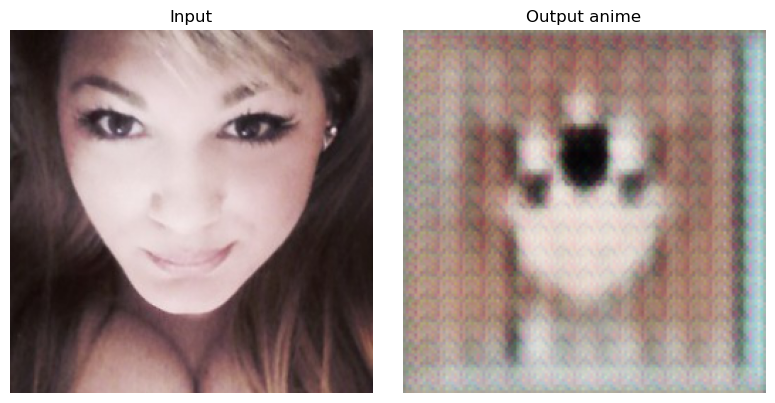

In [11]:
if generated_files:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(plt.imread(sorted(input_dir.glob('*'))[0]))
    axes[0].set_title('Input')
    axes[0].axis('off')
    axes[1].imshow(plt.imread(generated_files[0]))
    axes[1].set_title('Output anime')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

In [12]:
import gc
import torch

for _name in ("models", "history", "history_df", "loaders", "config"):
    if _name in globals():
        del globals()[_name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass

print("Mémoire libérée.")

Mémoire libérée.
